In [1]:
# importando as bibliotecas
import os
import torch
import torch.nn as nn
from torch.nn import functional as F

In [2]:
# lendo o corpus de wow
with open("/content/Wow_Corpus.txt", "r", encoding="utf-8") as f:
    text = f.read()

print(f"total de caracteres: {len(text)}")
print(f"total de palavras: {len(text.split())}")

total de caracteres: 22042
total de palavras: 2961


In [3]:
# visualizando o inicio
print(text[:500])

INTRODUCTION
Massively Multiplayer Online Role-Playing Games (MMORPGs) have developed into complex digital
ecosystems where narrative depth and interactive engagement shape player experience. In these large virtual
worlds, storytelling not only builds the world but also improves immersion, emotional involvement, and a sense
of agency. Despite their potential, most MMORPGs stick to pre-written quest lines, fixed dialogue options, and
scripted events that do not respond to player actions or the ch


In [4]:
# criando o vocabulario de caracteres unicos
chars = sorted(list(set(text)))
vocab_size = len(chars)
print("caracteres unicos:","".join(chars))
print("tamanho do vocabulario:", vocab_size)

caracteres unicos: 
 %&(),-./0123456789:;@ABCDEFGHIJKLMNOPRSTUVWXYabcdefghijklmnopqrstuvwxyz
tamanho do vocabulario: 73


In [5]:
# criando as funcoes de encode e decode
stoi = { ch:i for i,ch in enumerate(chars) } # char pra indice
itos = { i:ch for i,ch in enumerate(chars) } # indice pra char
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

# testando
print(encode("Illidan"))
print(decode(encode("Illidan")))

[31, 58, 58, 55, 50, 47, 60]
Illidan


In [6]:
# convertendo todo o texto em tensor
data = torch.tensor(encode(text), dtype=torch.long)
print(data.shape, data.dtype)
print(data[:50])

torch.Size([22042]) torch.int64
tensor([31, 36, 41, 39, 37, 26, 42, 25, 41, 31, 37, 36,  0, 35, 47, 65, 65, 55,
        68, 51, 58, 71,  1, 35, 67, 58, 66, 55, 62, 58, 47, 71, 51, 64,  1, 37,
        60, 58, 55, 60, 51,  1, 39, 61, 58, 51,  7, 38, 58, 47])


In [7]:
# dividindo em treino e validacao
n = int(0.9*len(data))
train_data = data[:n]
val_data = data[n:]
print(f"treino: {len(train_data)} tokens")
print(f" validacao: {len(val_data)} tokens")

treino: 19837 tokens
 validacao: 2205 tokens


In [8]:
# visualizando como contexto e alvo funciona
block_size = 64

x = train_data[:block_size]
y = train_data[1:block_size+1]

# mostrando os 5 primeiros pares
for t in range(5):
    ctx_str = decode(x[:t+1].tolist())
    tgt_str = decode([y[t].item()])
    # printa apenas o contexto um espaço e o alvo
    context = x[:t+1]
    target = y[t]
    print(f"contexto: {decode(context.tolist())!r:30s}")
    print(f"alvo:{decode([target.item()])!r}")

contexto: 'I'                           
alvo:'N'
contexto: 'IN'                          
alvo:'T'
contexto: 'INT'                         
alvo:'R'
contexto: 'INTR'                        
alvo:'O'
contexto: 'INTRO'                       
alvo:'D'


In [9]:
# definindo os hiperparametros
batch_size = 16
block_size = 64
max_iters = 5000
eval_interval = 250
learning_rate = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 100
n_embd = 64
n_head = 4
n_layer = 4
dropout = 0.2

print(device)
torch.manual_seed(42)

cuda


In [10]:
# funcao que sorteia um lote
def get_batch(split):
    d = train_data if split == 'train' else val_data
    ix = torch.randint(len(d) - block_size, (batch_size,))
    x = torch.stack([d[i:i+block_size] for i in ix])
    y = torch.stack([d[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

# funcao que estima a perda media
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

In [11]:
torch.manual_seed(1337)
B,T,C = 4,8,32
x = torch.randn(B,T,C)

# media acumulada dos tokens anteriores
xbow = torch.zeros((B,T,C))
for b in range(B):
    for t in range(T):
        xprev = x[b,:t+1]
        xbow[b,t] = xprev.mean(0)

In [12]:
# versao eficiente
tril = torch.tril(torch.ones(T,T))
wei = tril / tril.sum(1, keepdim=True)
xbow2 = wei @ x
print(torch.allclose(xbow, xbow2, atol=1e-6))

True


In [13]:
# versao com softmax
tril = torch.tril(torch.ones(T,T))
wei = torch.zeros((T,T))
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei, dim=-1)
xbow3 = wei @ x
print(torch.allclose(xbow, xbow3, atol=1e-4))

True


In [14]:
# atencao com projecoes
head_size = 16
key = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)
value = nn.Linear(C, head_size, bias=False)

k = key(x)
q = query(x)
wei = q @ k.transpose(-2,-1) * head_size**-0.5 # escala para estabilizar o gradiente

tril = torch.tril(torch.ones(T,T))
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei, dim=-1)

v = value(x)
out = wei @ v
print(out.shape)

torch.Size([4, 8, 16])


In [15]:
class Head(nn.Module):

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B,T,C = x.shape
        k = self.key(x)
        q = self.query(x)
        wei = q @ k.transpose(-2,-1) * C**-0.5
        wei = wei.masked_fill(self.tril[:T,:T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        v = self.value(x)
        return wei @ v

In [16]:
# multiplas rodando em paralelo
class MultiHeadAttention(nn.Module):

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd) # projecao para misturar as saidas
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1) # concatena todas as cabecas
        out = self.dropout(self.proj(out))
        return out

In [17]:
class FeedForward(nn.Module):

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(), # diferenca da aula que usava ReLU
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

In [18]:
# bloco transformer completo
class Block(nn.Module):

    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

In [19]:
# modelo de linguagem treinado no lore de wow
class WoWLanguageModel(nn.Module):

    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.positional_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd) # normalizacao final
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B,T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.positional_embedding_table(torch.arange(T, device=device))
        x = tok_emb + pos_emb # combina token e posicao
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        if targets is None:
            loss = None
        else:
            B,T,C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens, temperature=1.0):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits, loss = self(idx_cond)
            logits = logits[:, -1, :] / temperature # temperature controla a criatividade
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

model = WoWLanguageModel()
m = model.to(device)
print(f"parametros:{sum(p.numel() for p in model.parameters()):,}")

parametros:212,809


In [20]:
# gerando antes do treinamento pra ver o baseline
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(m.generate(context, max_new_tokens=200, temperature=1.0)[0].tolist()))


JnNVGME9Ta)ctBMWDRK@91PT7JF&1gT88(gDtY&VGy@wE2:MXzbjYYii17k
eRo6(Pv5(BXMB)Fi&xk%9qx.hkUevY;iKrX63lhDLnV%uVGaistI7nE-/Po20bp&gOq-osewKnHaSU UV%V@XHKwRk%GXVn77Oh5% )kTW0Eda7PR&a8d&5;PxU9AlxnIkCnE%njE2(6


In [22]:
# treinando o modelo
import matplotlib.pyplot as plt

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
train_losses = []
val_losses = []

for iter in range(max_iters):

    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        train_losses.append(losses['train'].item())
        val_losses.append(losses['val'].item())
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    xb, yb = get_batch('train')

    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

step 0: train loss 2.0786, val loss 2.7662
step 250: train loss 1.8862, val loss 2.7698
step 500: train loss 1.7118, val loss 2.7543
step 750: train loss 1.5700, val loss 2.6444
step 1000: train loss 1.4626, val loss 2.6394
step 1250: train loss 1.3380, val loss 2.7410
step 1500: train loss 1.2670, val loss 2.7413
step 1750: train loss 1.1828, val loss 2.7192
step 2000: train loss 1.1237, val loss 2.7740
step 2250: train loss 1.0672, val loss 2.7481
step 2500: train loss 1.0233, val loss 2.7480
step 2750: train loss 0.9640, val loss 2.7859
step 3000: train loss 0.9301, val loss 2.7900
step 3250: train loss 0.8885, val loss 2.8025
step 3500: train loss 0.8668, val loss 2.8693
step 3750: train loss 0.8312, val loss 2.8490
step 4000: train loss 0.8003, val loss 2.9504
step 4250: train loss 0.7731, val loss 2.9383
step 4500: train loss 0.7399, val loss 2.9199
step 4750: train loss 0.7270, val loss 3.0473
step 4999: train loss 0.6933, val loss 3.0728


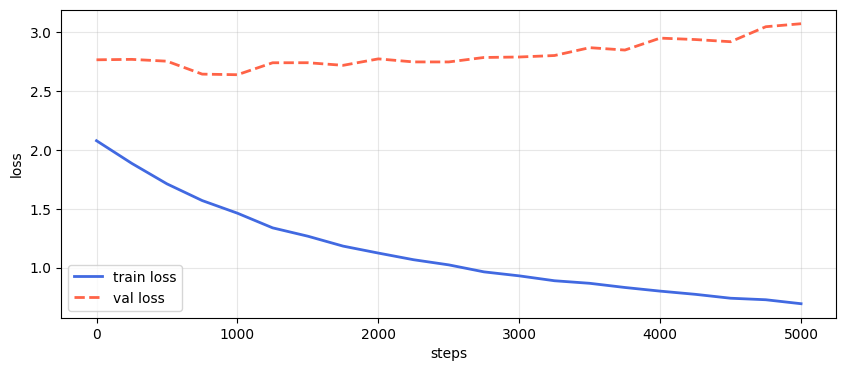

In [24]:
# plotando a curva de aprendizado
steps = list(range(0, max_iters+1, eval_interval))[:len(train_losses)]

plt.figure(figsize=(10,4))
plt.plot(steps, train_losses, label='train loss', color='royalblue', linewidth=2)
plt.plot(steps, val_losses, label='val loss', color='tomato', linewidth=2, linestyle='--')
plt.xlabel('steps')
plt.ylabel('loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [27]:
# gerando com 3 temperaturas diferentes pra comparar
for temp in [0.7, 1.0, 1.5]:
    print(f"temperature = {temp}")
    ctx = torch.zeros((1, 1), dtype=torch.long, device=device)
    print(decode(m.generate(ctx, max_new_tokens=300, temperature=temp)[0].tolist()))

temperature = 0.7

and open-timemes (MMORPG state narrative to content of the delitions offrom or also model maintailable narrative models (LLLM can been devations worlds has rave devid narrative quality the offir respon militions universal th mas case both odel with of delivers to worlds hightpolld indemelss in susta
temperature = 1.0

dynamic uning a stand generating pleaing, dialogue promined movid.
to duplare-plixibes, thou emonstributed how GPT-mainsis lore
LLMs ingly lignictional
essuest to psitall in presucturing an builimened nuraly spacter and heseare quating suall con lore-drivergen light narrative shas. As the especation
temperature = 1.5

Nachire quasing dyloing that balay shel-dorvenceificial
eency. Pradincing worlds susts howrild seronve Wfltir tongs. (Un the
mods ihardcold in LLLMd capacients
conver quring roludis,
cornoumrines,
tey multiple nhicloss familiate narrrative narratigals implemes hrecout uniesting of sytate-basion fine
